In [ ]:
#Mathematics and Statistics Assignment1 - Linear Algebra and Probability.
#Linear Algebra and Probability techniques to analyze the Wine Quality Dataset.
#The dataset consists of 1599 rows and 12 columns, detailing various chemical
#properties of red and white wines and their quality scores. The tasks will focus on vectors,
#matrices, eigenvalues, eigenvectors, and basic probability concepts.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

In [10]:
df=pd.read_csv('./drive/MyDrive/Data/winequality-red.csv', sep=';')

In [6]:
df

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
...,...
1594,6.2;0.6;0.08;2;0.09;32;44;0.9949;3.45;0.58;10.5;5
1595,5.9;0.55;0.1;2.2;0.062;39;51;0.99512;3.52;0.76...
1596,6.3;0.51;0.13;2.3;0.076;29;40;0.99574;3.42;0.7...
1597,5.9;0.645;0.12;2;0.075;32;44;0.99547;3.57;0.71...


In [ ]:
# 1.Load the dataset and handle any missing data by replacing null values with the mean
# value of the respective column.

In [7]:
print('Missing values before imputation:')
display(df.isnull().sum())

Missing values before imputation:


,0
"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality""",0


In [8]:
df_cleaned = df.copy()
for column in df_cleaned.columns:
    if df_cleaned[column].isnull().any():
        if pd.api.types.is_numeric_dtype(df_cleaned[column]):
            mean_value = df_cleaned[column].mean()
            df_cleaned[column].fillna(mean_value, inplace=True)
        else:
            # For non-numeric columns, fill with mode or a placeholder if necessary.
            # For this dataset, assuming all relevant columns are numeric.
            print(f"Warning: Column '{column}' is non-numeric and has missing values. Not imputing with mean.")

print('\nMissing values after imputation:')
display(df_cleaned.isnull().sum())


Missing values after imputation:


,0
"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality""",0


In [9]:
df = df_cleaned
display(df.head())

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [ ]:
# 2.Extract the following columns as vectors: alcohol,citric acid.

In [11]:
alcohol_vector = df['alcohol']
citric_acid_vector = df['citric acid']

print('Alcohol vector (first 5 values):')
display(alcohol_vector.head())

print('\nCitric Acid vector (first 5 values):')
display(citric_acid_vector.head())

Alcohol vector (first 5 values):


,alcohol
0,9.4
1,9.8
2,9.8
3,9.8
4,9.4



Citric Acid vector (first 5 values):


,citric acid
0,0.00
1,0.00
2,0.04
3,0.56
4,0.00


In [ ]:
# 3.Select two features (e.g., alcohol and density) from the dataset and calculate the
#covariance matrix using np.cov(X.T), where X is the feature matrix consisting of the
#selected columns.

In [12]:
import numpy as np

alcohol = df['alcohol'].values
density = df['density'].values

# Create a feature matrix X with alcohol and density
X = np.array([alcohol, density])

# Calculate the covariance matrix
covariance_matrix = np.cov(X)

print("Covariance Matrix of Alcohol and Density:")
display(covariance_matrix)

Covariance Matrix of Alcohol and Density:


array([[ 1.13564740e+00, -9.97951790e-04],
       [-9.97951790e-04,  3.56202945e-06]])

In [ ]:
# 4.Perform eigen decomposition on the covariance matrix you computed in question 3.
#Identify and interpret the results:Identify the top 2 eigenvalues of the covariance
#matrix,Identify the corresponding eigenvectors

In [13]:
from numpy import linalg as LA

# Perform eigen decomposition
eigenvalues, eigenvectors = LA.eig(covariance_matrix)

print("Eigenvalues:")
display(eigenvalues)

print("Eigenvectors:")
display(eigenvectors)

# Sort eigenvalues in descending order and get the indices
sorted_indices = np.argsort(eigenvalues)[::-1]
top_2_eigenvalues = eigenvalues[sorted_indices[:2]]
top_2_eigenvectors = eigenvectors[:, sorted_indices[:2]]

print("\nTop 2 Eigenvalues:")
display(top_2_eigenvalues)

print("\nCorresponding Top 2 Eigenvectors:")
display(top_2_eigenvectors)

Eigenvalues:


array([1.13564827e+00, 2.68507580e-06])

Eigenvectors:


array([[ 9.99999614e-01,  8.78753184e-04],
       [-8.78753184e-04,  9.99999614e-01]])


Top 2 Eigenvalues:


array([1.13564827e+00, 2.68507580e-06])


Corresponding Top 2 Eigenvectors:


array([[ 9.99999614e-01,  8.78753184e-04],
       [-8.78753184e-04,  9.99999614e-01]])

In [ ]:
# 5.Which wine quality is most common in the dataset? How can you interpret the
#distribution of wine quality scores?

In [14]:
most_common_quality = df['quality'].mode()[0]
print(f"The most common wine quality is: {most_common_quality}")

The most common wine quality is: 5


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


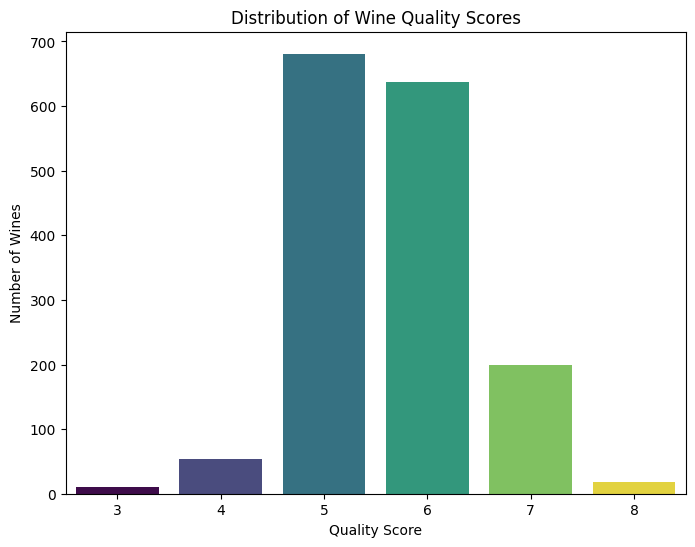

In [16]:
quality_counts = df['quality'].value_counts().sort_index()
display(quality_counts)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=quality_counts.index, y=quality_counts.values, hue=quality_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.show()